# Scenario: Evaluating Average Machine Operating Temperature

## Business Context:
A factory operates industrial machines that are supposed to maintain an operating temperature of 75°C. Deviations from this target can affect product quality.

The factory has historical data showing that the population standard deviation of operating temperatures is known and stable at 2°C.

The quality control team wants to check whether the machines operated within the expected range last month.


## Objective:
Determine if the average machine temperature last month differs significantly from the historical target of 75°C.

Demonstrate Q-Q plot to validate normality.

Calculate a 95% confidence interval using the known population standard deviation.

----



#### WHAT KIND OF TEST WOULD BE APPROPRIATE GIVEN THE INFORMATION?
....

<details>
  <summary>Compare Answer</summary>
  <p></p>
  Perform a Z-test for the mean.
</details>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import ztest


In [2]:
df = pd.read_csv("data/machine_temps.csv")
df.head()

,Day,Temperature
0,2025-09-01,76.993428
1,2025-09-02,75.723471
2,2025-09-03,77.295377
3,2025-09-04,79.046060
4,2025-09-05,75.531693


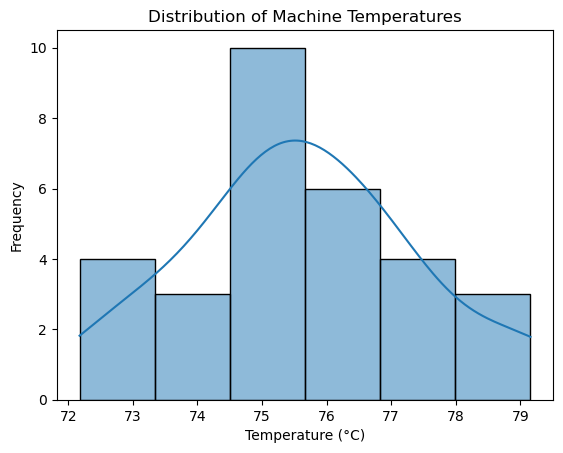

In [3]:
sns.histplot(df['Temperature'], kde=True)
plt.title("Distribution of Machine Temperatures")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

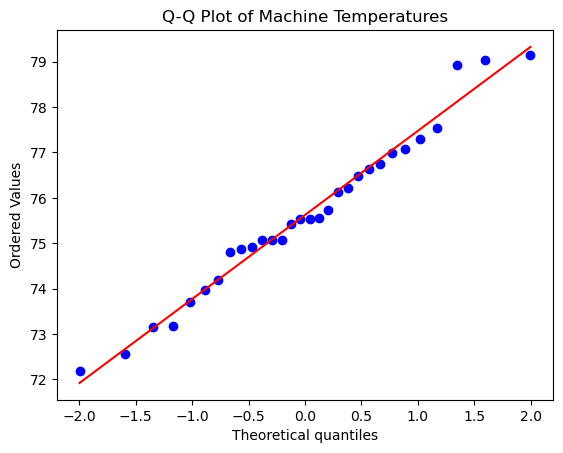

In [4]:
# Q-Q plot
stats.probplot(df['Temperature'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Machine Temperatures")
plt.show()

In [5]:
_, p_value_shapiro = stats.shapiro(df["Temperature"])
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.687


## Q-Q Plot Interpretation (Machine Temperatures Scenario):

Most of the points in the center of the Q-Q plot lie close to the diagonal line, suggesting that the bulk of the data is approximately normal.

A few points at the tails (about 3 on each side) deviate from the diagonal, indicating mild departures from normality in the extremes. This could be due to rare high or low temperature readings.

Overall, the deviations are small, so for practical purposes, we can treat the data as roughly normal.

## Shapiro-Wilk Test:

- Null hypothesis (H₀): The data is normally distributed.

- Alternative hypothesis (H₁): The data is not normally distributed.

- p-value: Measures the probability of observing the data if H₀ is true.

The Shapiro-Wilk test gave p = 0.687, which is greater than 0.05, meaning we fail to reject the null hypothesis that the data comes from a normal distribution.

This confirms the Q-Q plot interpretation: there is no strong evidence of non-normality.

## Takeaway for Analysis:

“The machine temperature data is roughly normal, with only minor deviations in the extreme values. Using tests that assume normality, like the Z-test, is reasonable in this scenario.”

# Calculate CI

In [6]:
sample = df['Temperature']
n = len(sample)
population_std = 2  # Known

# 95% CI using scipy
ci_lower, ci_upper = stats.norm.interval(0.95, loc=sample.mean(), scale=population_std/np.sqrt(n))
print(f"Sample Mean: {sample.mean():.2f}")
print(f"95% CI for average temperature: ({ci_lower:.2f}, {ci_upper:.2f})")


Sample Mean: 75.62
95% CI for average temperature: (74.91, 76.34)


# Perform the Z-test

In [7]:
population_mean = 75

# Z-test 
z_stat, p_value = ztest(sample, value=population_mean, alternative='two-sided')  # two-sided by default
print(f"Z-Statistic: {z_stat:.2f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Average temperature is significantly different from 75°C")
else:
    print("Fail to reject H0: No evidence that average temperature differs from 75°C")



Z-Statistic: 1.90, p-value: 0.0577
Fail to reject H0: No evidence that average temperature differs from 75°C


#  Interpretation in Business Terms

Confidence Interval:

“We are 95% confident that the true average machine temperature lies between 74.91 and 76.34 °C.”

Hypothesis Test:

“Since the p-value is  > 0.05, we fail to reject the null hypothesis”

Implications:

“This suggests that there is no strong evidence that the machines are operating outside the target temperature. The machines appear to be functioning as expected, so no immediate adjustments are necessary. Maintenance or quality teams can continue monitoring but do not need to take corrective action based on this data.”

# NOTE IF WE FAILED TO IDENTIFY THE TEST "SIDEDNESS" INCORRECTLY

In [8]:
population_mean = 75

# Z-test 
z_stat, p_value = ztest(sample, value=population_mean, alternative='larger')  # two-sided by default
print(f"Z-Statistic: {z_stat:.2f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Average temperature is significantly different from 75°C")
else:
    print("Fail to reject H0: No evidence that average temperature differs from 75°C")

Z-Statistic: 1.90, p-value: 0.0289
Reject H0: Average temperature is significantly different from 75°C
